# Clasificación CN vs AD y transferencia a MCI vs AD

Este notebook implementa un pipeline completo de *machine learning* para la clasificación binaria de sujetos con **Alzheimer's Disease (AD)** frente a controles cognitivamente normales (**CN**), a partir de biomarcadores estructurales derivados de FreeSurfer.

El flujo de trabajo se estructura en dos etapas principales:

1. **Selección de ROIs discriminativas** mediante un pipeline CN vs AD con Elastic Net y Random Forest, optimizado con `GridSearchCV`
2. **Transferencia de las ROIs seleccionadas** a un nuevo problema de clasificación **MCI vs AD**, con optimización bayesiana de hiperparámetros mediante Optuna

## 1. Importación de librerías

## 2. Carga y preparación de datos — CN vs AD

Se cargan los datos de los cuatro grupos (AD masculino, AD femenino, CN masculino, CN femenino) y se asignan etiquetas binarias:

| Grupo | Etiqueta |
|---|---|
| CN (masculino / femenino) | `0` |
| AD (masculino / femenino) | `1` |

Se excluyen columnas no informativas o con alta proporción de valores nulos antes de construir la matriz de características $X$:

- `subject` — identificador del sujeto
- `ICV` — volumen intracraneal (variable de normalización ya aplicada)
- `5th-Ventricle`, `Left/Right-WM-hypointensities`, `non-WM-hypointensities` — regiones con baja fiabilidad o escasa varianza en la muestra

## 3. Pipeline CN vs AD — Elastic Net + Random Forest

Se construye un pipeline de tres etapas para la clasificación **CN vs AD**:

1. **`StandardScaler`** — estandarización de todas las variables a media 0 y desviación típica 1
2. **`SelectFromModel` (Elastic Net)** — selección de ROIs mediante regresión logística con penalización combinada L1+L2. El parámetro `l1_ratio` controla el balance entre ambas regularizaciones
3. **`RandomForestClassifier`** — clasificador final de tipo ensamblado, robusto ante relaciones no lineales

Ambos modelos emplean `class_weight='balanced'` para compensar el posible desbalanceo entre clases.

La búsqueda de hiperparámetros se realiza mediante **`GridSearchCV`** con validación cruzada estratificada de 5 pliegues, optimizando la **Balanced Accuracy** como métrica principal. Se evalúan simultáneamente seis métricas:

| Métrica | Descripción |
|---|---|
| `balanced_accuracy` | Media aritmética de sensibilidad y especificidad |
| `f1` | Media armónica de precisión y recall |
| `precision` | Fracción de positivos predichos correctamente |
| `recall` | Sensibilidad (fracción de AD detectados) |
| `roc_auc` | Área bajo la curva ROC |
| `specificity` | Recall de la clase negativa (CN) |

## 4. Transferencia a MCI vs AD — Carga y preparación de datos

Las ROIs seleccionadas en el paso anterior se utilizan ahora como espacio de características para un nuevo problema de clasificación: **MCI vs AD**.

Se trabaja con cuatro subgrupos de MCI estratificados por sexo y estadio:

| Grupo | Estadio | Etiqueta |
|---|---|---|
| EMCI masculino / femenino | MCI temprano | `0` |
| LMCI masculino / femenino | MCI tardío | `0` |
| AD masculino / femenino | Alzheimer | `1` |

Dado que los grupos MCI tienen mayor número de sujetos disponibles, se aplica **submuestreo aleatorio** a 30 muestras por subgrupo para evitar que el clasificador se sesgue hacia la clase mayoritaria.

## 5. Optimización bayesiana de hiperparámetros con Optuna — MCI vs AD

Para el problema MCI vs AD se abandona el grid exhaustivo y se emplea **Optuna** con el muestreador **TPE** (*Tree-structured Parzen Estimator*), que modela la distribución de hiperparámetros prometedores de forma adaptativa.

Los hiperparámetros optimizados y sus rangos de búsqueda son:

| Hiperparámetro | Rango |
|---|---|
| `n_estimators` | [1, 1000] |
| `max_depth` | [1, 30] |
| `min_samples_split` | [2, 30] |
| `min_samples_leaf` | [1, 30] |

La función objetivo maximiza la **Balanced Accuracy** media en validación cruzada estratificada de 5 pliegues. Se ejecutan **10.000 trials** para garantizar una exploración exhaustiva del espacio de búsqueda.

Tras la optimización se analiza el **top 1% de los trials** para identificar los rangos óptimos de cada hiperparámetro mediante estadísticas descriptivas.

## 6. Entrenamiento y evaluación del modelo final MCI vs AD

Con los hiperparámetros óptimos encontrados por Optuna se construye el **modelo Random Forest final** y se evalúa su rendimiento:

- **Métricas CV** — evaluación sobre el conjunto completo mediante validación cruzada estratificada
- **Métricas test** — evaluación sobre el 20% de datos reservados

La comparación entre ambas permite detectar posible sobreajuste. Se espera que la clasificación MCI vs AD sea más difícil que CN vs AD, dado que MCI representa un estadio intermedio con mayor solapamiento morfológico respecto a AD.

## 7. GridSearch refinado sobre MCI vs AD

A partir de los rangos óptimos identificados en el top 1% de los trials de Optuna, se construye un **grid de búsqueda refinado** con un espacio de hiperparámetros más acotado. Esto permite:

- Explorar con mayor granularidad la región de mayor rendimiento
- Obtener un modelo reproducible y auditable mediante `GridSearchCV`
- Incorporar `StandardScaler` en el pipeline de forma explícita

El grid refinado cubre los siguientes rangos, derivados del análisis del top 1% de Optuna:

| Hiperparámetro | Rango refinado |
|---|---|
| `n_estimators` | [350, 470] |
| `max_depth` | [10, 25] |
| `min_samples_split` | [24, 30] |
| `min_samples_leaf` | [1, 2] |

## 8. Ajuste de umbral de decisión y Análisis de Curva de Decisión Clínica (DCA)

El umbral de clasificación por defecto (0.5) maximiza la precisión global pero no necesariamente el **recall de AD**, que en contexto clínico tiene alta prioridad: un falso negativo (paciente AD clasificado como MCI) puede retrasar el diagnóstico y tratamiento.

Adicionalmente, se construye una **Curva de Decisión Clínica (DCA)** que evalúa el beneficio neto del modelo frente a las estrategias extremas de tratar a todos o no tratar a nadie:

donde $p_t$ es el umbral de probabilidad y $n$ el total de sujetos. La DCA se calcula sobre predicciones OOF de validación cruzada para evitar sobreestimación del beneficio.

c:\Users\PcVip\miniconda3\envs\hyper_analysis\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fitting 5 folds for each of 2160 candidates, totalling 10800 fits
Mejores parámetros encontrados:
{'rf__max_depth': 5, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 10, 'rf__n_estimators': 50, 'selector__estimator__l1_ratio': 0.3, 'selector__max_features': 8}

===== RESUMEN DE MÉTRICAS =====


,Metric,Value
0,F1-score (test),0.904762
1,F1-score (validación),0.911468
2,ROC-AUC (test),0.984127
3,ROC-AUC (validación),0.937784
4,Balanced Accuracy (test),0.915344
5,Balanced Accuracy (validación),0.919468
6,Precision (test),0.904762
7,Precision (validación),0.931656
8,Recall (Sensitivity) (test),0.904762
9,Recall (Sensitivity) (validación),0.896078


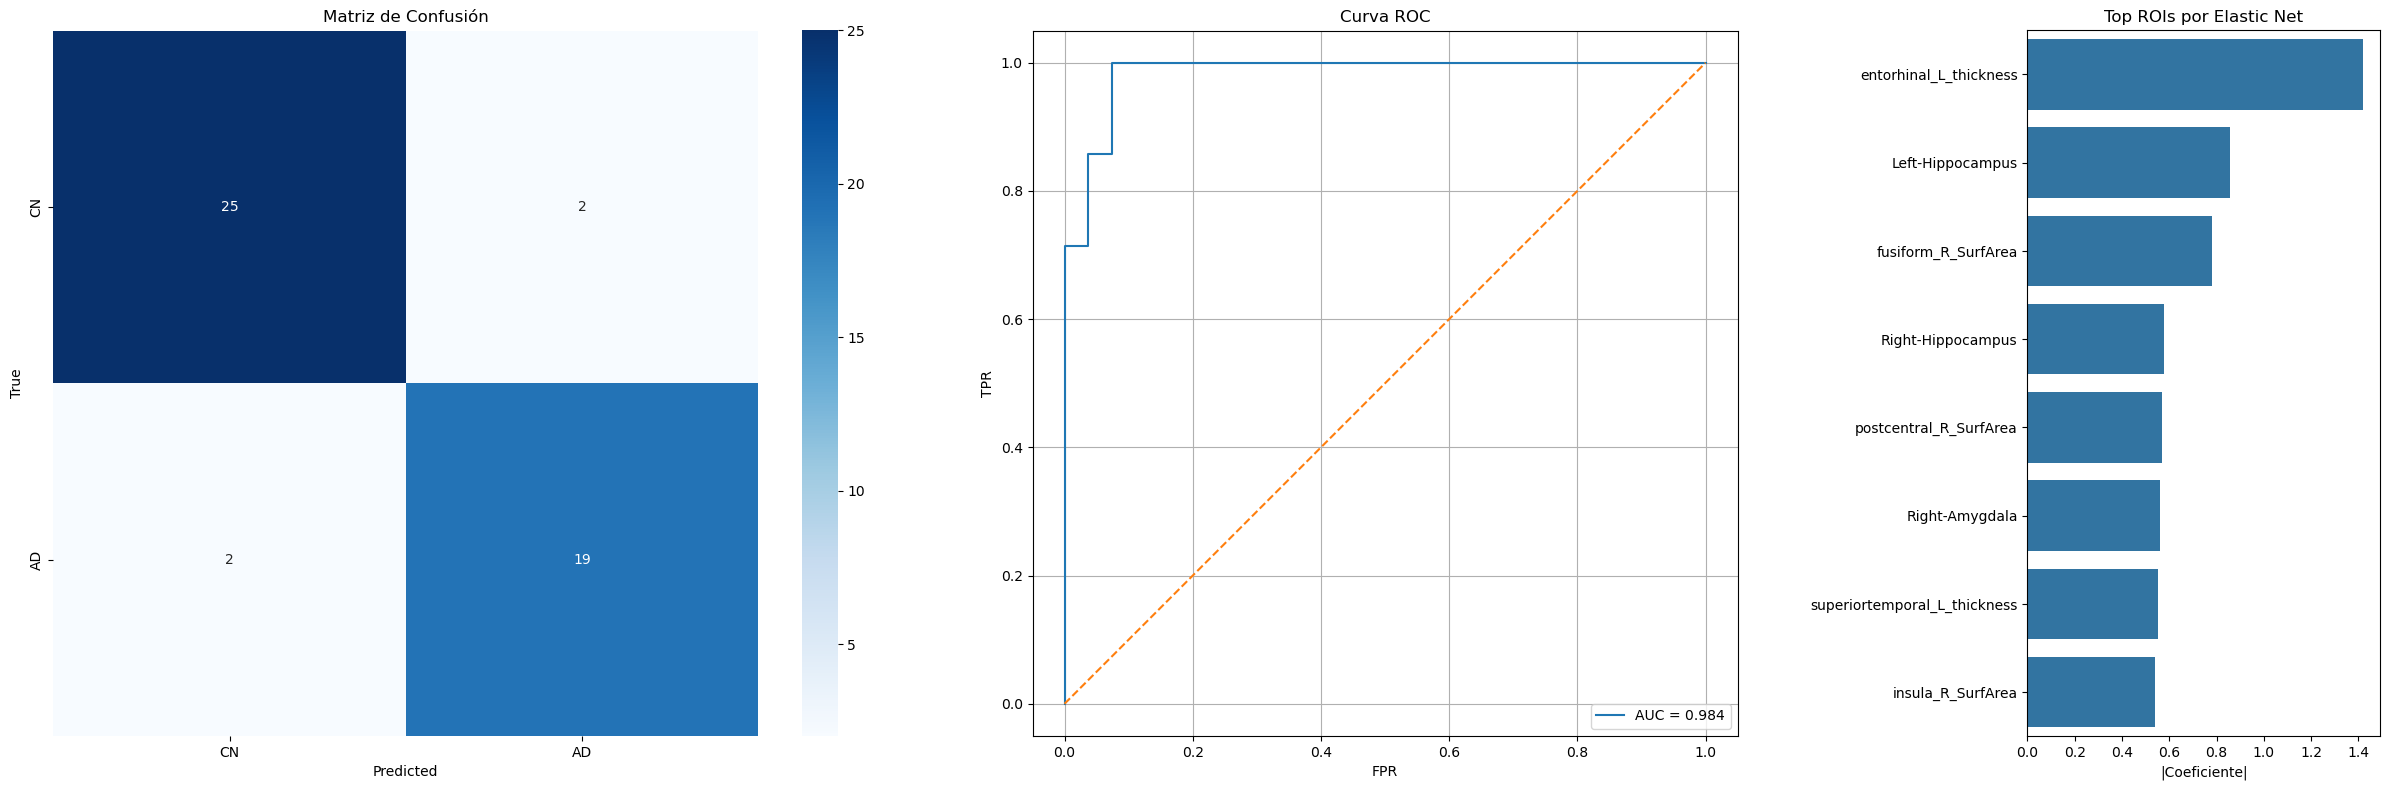


Las 8 ROIs seleccionadas son:
['Left-Hippocampus', 'Right-Hippocampus', 'Right-Amygdala', 'entorhinal_L_thickness', 'superiortemporal_L_thickness', 'fusiform_R_SurfArea', 'postcentral_R_SurfArea', 'insula_R_SurfArea']

===== RANKING COMPLETO DE FEATURES (Elastic Net) =====


,Feature,Coefficient
0,entorhinal_L_thickness,-1.420567
1,Left-Hippocampus,-0.855237
2,fusiform_R_SurfArea,-0.781358
3,Right-Hippocampus,-0.578123
4,postcentral_R_SurfArea,0.569980
5,Right-Amygdala,-0.560298
6,superiortemporal_L_thickness,-0.554191
7,insula_R_SurfArea,0.539846
8,frontalpole_R_thickness,0.529618
9,supramarginal_L_SurfArea,-0.525649


c:\Users\PcVip\miniconda3\envs\hyper_analysis\lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-04-24 18:01:15,961] A new study created in memory with name: no-name-fca9d335-cf33-4ebd-9a04-d54641db3344
[I 2026-04-24 18:01:16,351] Trial 0 finished with value: 0.7414502164502166 and parameters: {'n_estimators': 375, 'max_depth': 29, 'min_samples_split': 23, 'min_samples_leaf': 18}. Best is trial 0 with value: 0.7414502164502166.
[I 2026-04-24 18:01:16,540] Trial 1 finished with value: 0.736525974025974 and parameters: {'n_estimators': 157, 'max_depth': 5, 'min_samples_split': 3, 'min_samples_leaf': 26}. Best is trial 0 with value: 0.7414502164502166.
[I 2026-04-24 18:01:17,094] Trial 2 finished with value: 0.7412878787878787 and parameters: {'n_estimators': 602, 'max_depth': 22, 'min_samples_split': 2, 'min_samples_leaf': 30}. Best is trial 0 with value: 0


===== BEST OPTUNA RESULT — RANDOM FOREST =====
{'n_estimators': 413, 'max_depth': 10, 'min_samples_split': 30, 'min_samples_leaf': 1}
Best score: 0.7830627705627705

===== IMPORTANCIA HIPERPARAMETROS — RF =====
min_samples_leaf: 0.7562
n_estimators: 0.2207
max_depth: 0.0210
min_samples_split: 0.0020

===== RANGOS OPTIMOS (TOP 1%) — RF =====

N estimators:
count    100.000000
mean     343.890000
std      123.171138
min       77.000000
25%      244.500000
50%      398.500000
75%      416.000000
max      737.000000
Name: params_n_estimators, dtype: float64

Max depth:
count    100.000000
mean      16.750000
std        6.569558
min        5.000000
25%       11.000000
50%       16.000000
75%       22.000000
max       29.000000
Name: params_max_depth, dtype: float64

Min samples split:
count    100.000000
mean      26.260000
std        1.936466
min       18.000000
25%       25.000000
50%       26.000000
75%       27.000000
max       30.000000
Name: params_min_samples_split, dtype: float64



In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
from optuna.importance import get_param_importances

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_f.csv")
df_cn_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_cn_m.csv")
df_cn_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV", "5th-Ventricle", "Left-WM-hypointensities", "Right-WM-hypointensities", "non-WM-hypointensities", "Left-non-WM-hypointensities", "Right-non-WM-hypointensities"])
y = df["label"]

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Regresión logística con penalización Elastic Net
elastic = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    max_iter=10000,
    random_state=21,
    class_weight='balanced' 
)

# Selector de features basado en el modelo Elastic Net con balanceo de clases
selector = SelectFromModel(elastic, threshold=-np.inf)

# Pipeline completo: escalado -> selección de features -> Random Forest final
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', selector),
    ('rf',  RandomForestClassifier(random_state=34, class_weight='balanced')) # Random Forest con balanceo de clases desiguales
])

# Grid de hiperparámetros para GridSearchCV
param_grid = {
    'selector__estimator__l1_ratio': [0.3, 0.5, 0.7],
    'selector__max_features': list(range(1, 21)),
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [2, 3, 5],
    'rf__min_samples_split': [5, 10],
    'rf__min_samples_leaf': [2, 4]
}

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros encontrados
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Coeficientes del selector
coef_selector = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Índices y nombres de features seleccionadas
selected_idx = grid.best_estimator_.named_steps['selector'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1, 0.5]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot coeficientes ---
coef_df = pd.DataFrame({
    "feature": X.columns[selected_idx],
    "coef": coef_selector[selected_idx]
})

coef_df["abs_coef"] = np.abs(coef_df["coef"])
coef_df = coef_df.sort_values("abs_coef", ascending=False)

sns.barplot(data=coef_df, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por Elastic Net')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.04,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas son:")
print(feature_names.tolist())

# Extraer los coeficientes del modelo Elastic Net usado en el selector
coef_arr = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Construir DataFrame con todas las features
ranking_df = pd.DataFrame({
    'Feature': X.columns,        # Nombre de cada ROI
    'Coefficient': coef_arr,     # Coeficiente asignado por Elastic Net
})

# Ordenar por importancia global (de mayor a menor |coef|)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (Elastic Net) =====")
display(ranking_df)

# coeficientes del Elastic Net dentro del selector
selected_idx = grid.best_estimator_.named_steps['selector'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# Lectura de CSVs por grupo, diagnóstico y sexo
df_ad_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_f.csv")
df_emci_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_emci_m.csv")
df_lmci_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_lmci_m.csv")
df_emci_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_emci_f.csv")
df_lmci_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_lmci_f.csv")

# Submuestreo de grupos MCI a 30 muestras por subgrupo para balancear clases
df_emci_m = df_emci_m.sample(n=30, random_state=2)
df_emci_f = df_emci_f.sample(n=30, random_state=3)
df_lmci_m = df_lmci_m.sample(n=30, random_state=5)
df_lmci_f = df_lmci_f.sample(n=30, random_state=8)

# Crear etiquetas (label) por grupo
# 0 -> MCI (EMCI + LMCI), 1 -> AD
df_emci_m["label"] = 0
df_lmci_m["label"] = 0
df_emci_f["label"] = 0
df_lmci_f["label"] = 0
df_ad_m["label"] = 1
df_ad_f["label"] = 1

# Concatenar todos los dataframes en uno solo
df_new = pd.concat([
    df_emci_m, df_lmci_m,
    df_emci_f, df_lmci_f,
    df_ad_f, df_ad_m
], ignore_index=True)

# Separar features (usando las ROIs seleccionadas previamente) y etiquetas
X_new = df_new[feature_names]
y_new = df_new["label"].values

# Función para calcular métricas promedio con validación cruzada
def cv_metrics(pipe, X, y, cv):

    # Diccionario de métricas a evaluar
    scoring = {
        "balanced_accuracy": "balanced_accuracy",
        "precision": make_scorer(precision_score),
        "recall": make_scorer(recall_score),
        "f1": make_scorer(f1_score),
        "roc_auc": "roc_auc"
    }

    results = {}

    # Calcular cada métrica mediante cross_val_score
    for name, scorer in scoring.items():
        scores = cross_val_score(pipe, X, y, cv=cv, scoring=scorer, n_jobs=-1)
        results[name] = (scores.mean(), scores.std())

    return results

# Función objetivo para optimización de hiperparámetros con Optuna
def objective_rf(trial):

    # Sugerir valores para los hiperparámetros a optimizar
    n_estimators = trial.suggest_int("n_estimators", 1, 1000)
    max_depth = trial.suggest_int("max_depth", 1, 30)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 30)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 30)

    # Crear modelo Random Forest con los parámetros sugeridos
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        class_weight="balanced",  # Fijo a "balanced" para manejar desbalanceo
        random_state=34,
        n_jobs=-1
    )

    # Pipeline simple con el modelo
    pipe = Pipeline([
        ("model", model)
    ])

    # Métrica a optimizar: balanced accuracy
    balanced_acc_scorer = make_scorer(balanced_accuracy_score)

    # Retornar el promedio de balanced accuracy en validación cruzada
    return cross_val_score(pipe, X_new, y_new, cv=cv, scoring=balanced_acc_scorer, n_jobs=-1).mean()

# Configuración y ejecución de Optuna
study_rf = optuna.create_study(
    direction="maximize",  # Maximizar la métrica objetivo
    sampler=optuna.samplers.TPESampler(n_startup_trials=5000, seed=42, multivariate=True)  # Muestreador TPE con semilla fija
)

study_rf.optimize(objective_rf, n_trials=10000)  # Ejecutar 10,000 trials de optimización

# Mostrar mejores parámetros encontrados por Optuna
print("\n===== BEST OPTUNA RESULT — RANDOM FOREST =====")
print(study_rf.best_params)
print("Best score:", study_rf.best_value)

# Calcular importancia de cada hiperparámetro en la optimización
importances_rf = get_param_importances(study_rf)

print("\n===== IMPORTANCIA HIPERPARAMETROS — RF =====")
for k, v in importances_rf.items():
    print(f"{k}: {v:.4f}")

# Extraer rangos óptimos del top 1% de los trials
trials_df_rf = study_rf.trials_dataframe()
top_n_rf = int(len(trials_df_rf) * 0.01)  # Calcular 1% del total de trials
top_trials_rf = trials_df_rf.sort_values("value", ascending=False).head(top_n_rf)

print("\n===== RANGOS OPTIMOS (TOP 1%) — RF =====")

# Mostrar estadísticas descriptivas de los mejores hiperparámetros
print("\nN estimators:")
print(top_trials_rf["params_n_estimators"].describe())

print("\nMax depth:")
print(top_trials_rf["params_max_depth"].describe())

print("\nMin samples split:")
print(top_trials_rf["params_min_samples_split"].describe())

print("\nMin samples leaf:")
print(top_trials_rf["params_min_samples_leaf"].describe())

# División estratificada en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_new, y_new, test_size=0.2, stratify=y_new, random_state=13
)

# Recuperar mejores hiperparámetros encontrados por Optuna
best_rf = study_rf.best_params

# Construir modelo Random Forest final con los mejores parámetros
rf_final = RandomForestClassifier(
    n_estimators=best_rf["n_estimators"],
    max_depth=best_rf["max_depth"],
    min_samples_split=best_rf["min_samples_split"],
    min_samples_leaf=best_rf["min_samples_leaf"],
    class_weight="balanced",  # Fijo a "balanced"
    random_state=34,
    n_jobs=-1
)

# Pipeline final
pipe_final_rf = Pipeline([
    ("model", rf_final)
])

# Entrenar el modelo final
pipe_final_rf.fit(X_train, y_train)

# Predicciones sobre conjunto de test
y_pred_rf = pipe_final_rf.predict(X_test)
y_prob_rf = pipe_final_rf.predict_proba(X_test)[:, 1]

print("\n===== CV METRICS — RANDOM FOREST =====")
cv_rf = cv_metrics(pipe_final_rf, X_new, y_new, cv)

for k, v in cv_rf.items():
    print(f"{k}: {v[0]:.3f} ± {v[1]:.3f}")

print("\n===== TEST METRICS — RANDOM FOREST =====")

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_rf))

c:\Users\PcVip\miniconda3\envs\hyper_analysis\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fitting 5 folds for each of 2160 candidates, totalling 10800 fits
Mejores parámetros encontrados:
{'rf__max_depth': 5, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 10, 'rf__n_estimators': 50, 'selector__estimator__l1_ratio': 0.3, 'selector__max_features': 8}

===== RESUMEN DE MÉTRICAS =====


,Metric,Value
0,F1-score (test),0.904762
1,F1-score (validación),0.911468
2,ROC-AUC (test),0.984127
3,ROC-AUC (validación),0.937784
4,Balanced Accuracy (test),0.915344
5,Balanced Accuracy (validación),0.919468
6,Precision (test),0.904762
7,Precision (validación),0.931656
8,Recall (Sensitivity) (test),0.904762
9,Recall (Sensitivity) (validación),0.896078


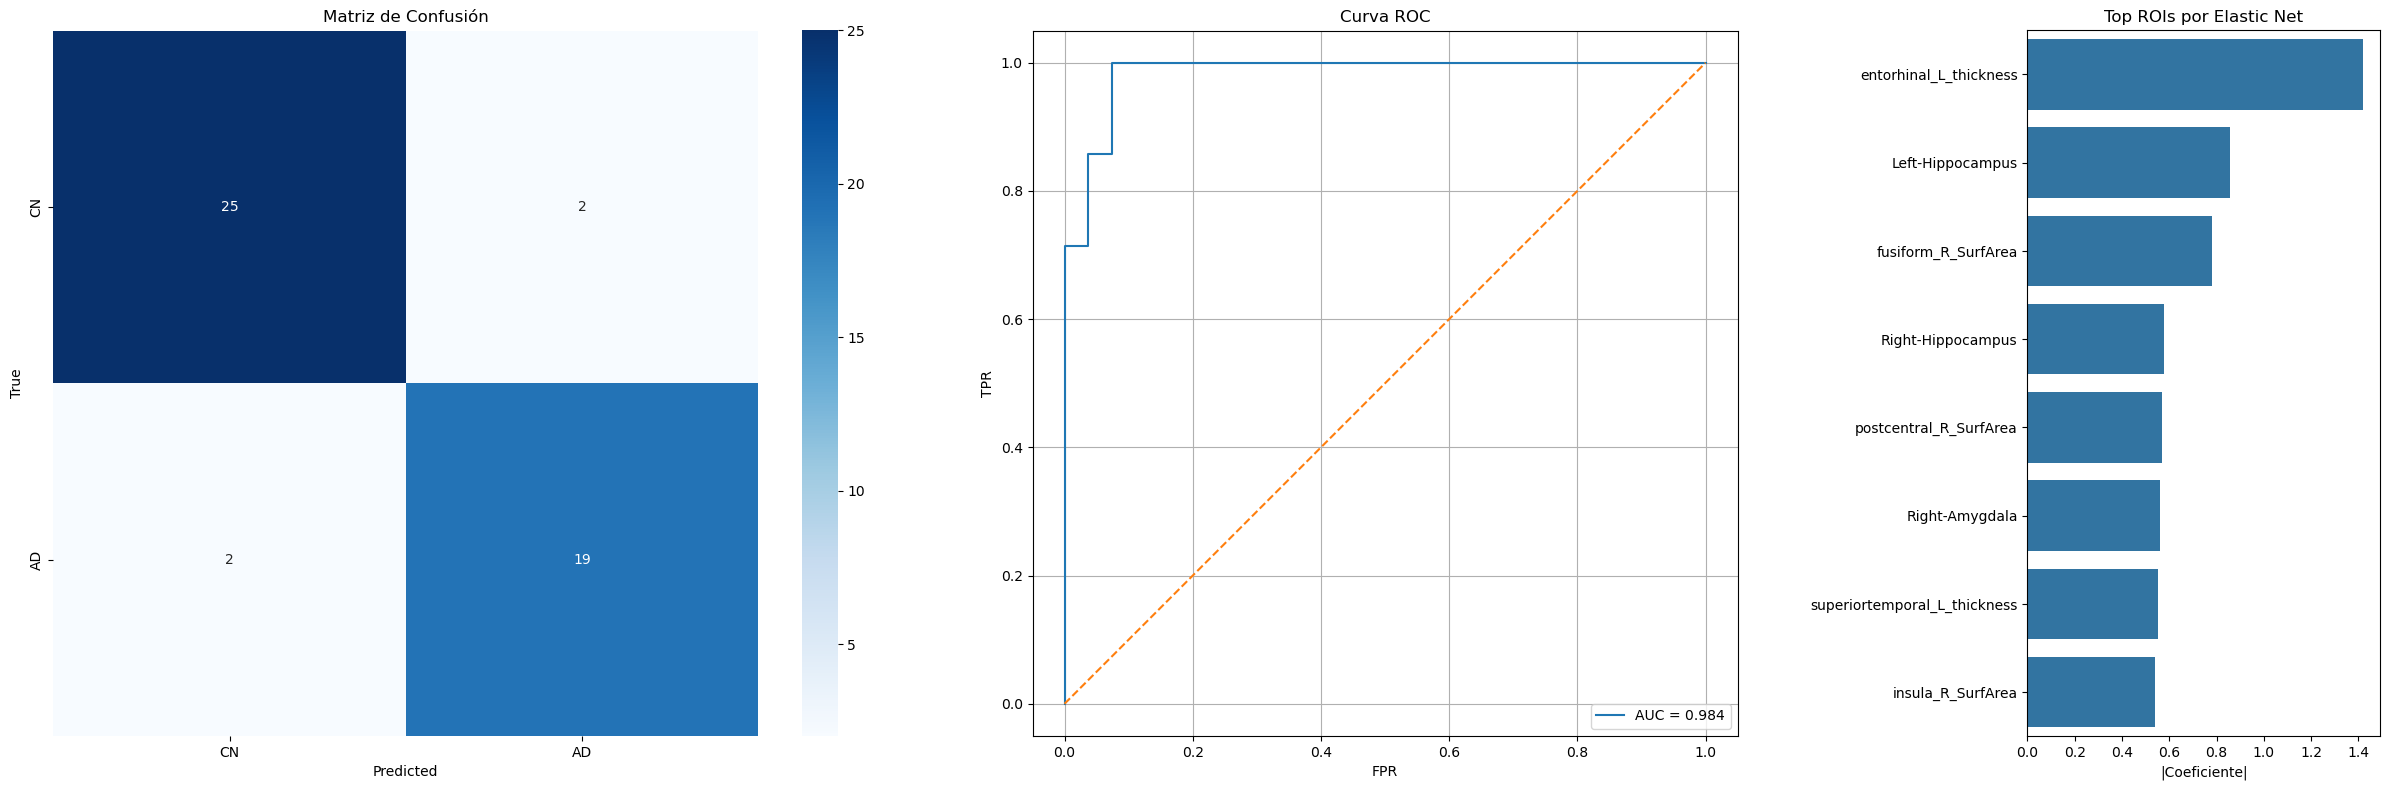


Las 8 ROIs seleccionadas son:
['Left-Hippocampus', 'Right-Hippocampus', 'Right-Amygdala', 'entorhinal_L_thickness', 'superiortemporal_L_thickness', 'fusiform_R_SurfArea', 'postcentral_R_SurfArea', 'insula_R_SurfArea']

===== RANKING COMPLETO DE FEATURES (Elastic Net) =====


,Feature,Coefficient
0,entorhinal_L_thickness,-1.420567
1,Left-Hippocampus,-0.855237
2,fusiform_R_SurfArea,-0.781358
3,Right-Hippocampus,-0.578123
4,postcentral_R_SurfArea,0.569980
5,Right-Amygdala,-0.560298
6,superiortemporal_L_thickness,-0.554191
7,insula_R_SurfArea,0.539846
8,frontalpole_R_thickness,0.529618
9,supramarginal_L_SurfArea,-0.525649


c:\Users\PcVip\miniconda3\envs\hyper_analysis\lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-04-24 13:49:35,182] A new study created in memory with name: no-name-6e210d63-eb1a-46ff-8fd2-e702b05445bf
[I 2026-04-24 13:49:35,293] Trial 0 finished with value: 0.7272186147186147 and parameters: {'n_estimators': 34, 'max_depth': 15, 'min_samples_split': 26, 'min_samples_leaf': 13}. Best is trial 0 with value: 0.7272186147186147.
[I 2026-04-24 13:49:35,985] Trial 1 finished with value: 0.7602813852813852 and parameters: {'n_estimators': 632, 'max_depth': 9, 'min_samples_split': 17, 'min_samples_leaf': 7}. Best is trial 1 with value: 0.7602813852813852.
[I 2026-04-24 13:49:36,285] Trial 2 finished with value: 0.7638528138528139 and parameters: {'n_estimators': 241, 'max_depth': 29, 'min_samples_split': 20, 'min_samples_leaf': 1}. Best is trial 2 with value: 0


===== BEST OPTUNA RESULT — RANDOM FOREST =====
{'n_estimators': 559, 'max_depth': 19, 'min_samples_split': 29, 'min_samples_leaf': 2}
Best score: 0.7830627705627705

===== IMPORTANCIA HIPERPARAMETROS — RF =====
min_samples_leaf: 0.7888
n_estimators: 0.1892
max_depth: 0.0197
min_samples_split: 0.0023

===== RANGOS OPTIMOS (TOP 1%) — RF =====

N estimators:
count    100.000000
mean     380.820000
std      124.868042
min       53.000000
25%      390.000000
50%      408.000000
75%      421.250000
max      719.000000
Name: params_n_estimators, dtype: float64

Max depth:
count    100.000000
mean      18.400000
std        6.316565
min        6.000000
25%       14.000000
50%       18.000000
75%       24.000000
max       30.000000
Name: params_max_depth, dtype: float64

Min samples split:
count    100.000000
mean      26.180000
std        1.328628
min       23.000000
25%       25.000000
50%       26.000000
75%       27.000000
max       30.000000
Name: params_min_samples_split, dtype: float64



In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
from optuna.importance import get_param_importances

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_f.csv")
df_cn_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_cn_m.csv")
df_cn_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV", "5th-Ventricle", "Left-WM-hypointensities", "Right-WM-hypointensities", "non-WM-hypointensities", "Left-non-WM-hypointensities", "Right-non-WM-hypointensities"])
y = df["label"]

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Regresión logística con penalización Elastic Net
elastic = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    max_iter=10000,
    random_state=21,
    class_weight='balanced' 
)

# Selector de features basado en el modelo Elastic Net con balanceo de clases
selector = SelectFromModel(elastic, threshold=-np.inf)

# Pipeline completo: escalado -> selección de features -> Random Forest final
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', selector),
    ('rf',  RandomForestClassifier(random_state=34, class_weight='balanced')) # Random Forest con balanceo de clases desiguales
])

# Grid de hiperparámetros para GridSearchCV
param_grid = {
    'selector__estimator__l1_ratio': [0.3, 0.5, 0.7],
    'selector__max_features': list(range(1, 21)),
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [2, 3, 5],
    'rf__min_samples_split': [5, 10],
    'rf__min_samples_leaf': [2, 4]
}

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros encontrados
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Coeficientes del selector
coef_selector = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Índices y nombres de features seleccionadas
selected_idx = grid.best_estimator_.named_steps['selector'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1, 0.5]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot coeficientes ---
coef_df = pd.DataFrame({
    "feature": X.columns[selected_idx],
    "coef": coef_selector[selected_idx]
})

coef_df["abs_coef"] = np.abs(coef_df["coef"])
coef_df = coef_df.sort_values("abs_coef", ascending=False)

sns.barplot(data=coef_df, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por Elastic Net')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.04,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas son:")
print(feature_names.tolist())

# Extraer los coeficientes del modelo Elastic Net usado en el selector
coef_arr = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Construir DataFrame con todas las features
ranking_df = pd.DataFrame({
    'Feature': X.columns,        # Nombre de cada ROI
    'Coefficient': coef_arr,     # Coeficiente asignado por Elastic Net
})

# Ordenar por importancia global (de mayor a menor |coef|)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (Elastic Net) =====")
display(ranking_df)

# coeficientes del Elastic Net dentro del selector
selected_idx = grid.best_estimator_.named_steps['selector'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# Lectura de CSVs por grupo, diagnóstico y sexo
df_ad_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_f.csv")
df_emci_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_emci_m.csv")
df_lmci_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_lmci_m.csv")
df_emci_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_emci_f.csv")
df_lmci_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_lmci_f.csv")

# Submuestreo de grupos MCI a 30 muestras por subgrupo para balancear clases
df_emci_m = df_emci_m.sample(n=30, random_state=2)
df_emci_f = df_emci_f.sample(n=30, random_state=3)
df_lmci_m = df_lmci_m.sample(n=30, random_state=5)
df_lmci_f = df_lmci_f.sample(n=30, random_state=8)

# Crear etiquetas (label) por grupo
# 0 -> MCI (EMCI + LMCI), 1 -> AD
df_emci_m["label"] = 0
df_lmci_m["label"] = 0
df_emci_f["label"] = 0
df_lmci_f["label"] = 0
df_ad_m["label"] = 1
df_ad_f["label"] = 1

# Concatenar todos los dataframes en uno solo
df_new = pd.concat([
    df_emci_m, df_lmci_m,
    df_emci_f, df_lmci_f,
    df_ad_f, df_ad_m
], ignore_index=True)

# Separar features (usando las ROIs seleccionadas previamente) y etiquetas
X_new = df_new[feature_names]
y_new = df_new["label"].values

# Función para calcular métricas promedio con validación cruzada
def cv_metrics(pipe, X, y, cv):

    # Diccionario de métricas a evaluar
    scoring = {
        "balanced_accuracy": "balanced_accuracy",
        "precision": make_scorer(precision_score, pos_label=1),
        "recall": make_scorer(recall_score, pos_label=1),
        "f1": make_scorer(f1_score, pos_label=1),
        "accuracy": "accuracy",
        "roc_auc": "roc_auc"
    }

    results = {}

    # Calcular cada métrica mediante cross_val_score
    for name, scorer in scoring.items():
        scores = cross_val_score(pipe, X, y, cv=cv, scoring=scorer, n_jobs=-1)
        results[name] = (scores.mean(), scores.std())

    return results

# Función objetivo para optimización de hiperparámetros con Optuna
def objective_rf(trial):

    # Sugerir valores para los hiperparámetros a optimizar
    n_estimators = trial.suggest_int("n_estimators", 1, 1000)
    max_depth = trial.suggest_int("max_depth", 1, 30)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 30)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 30)

    # Crear modelo Random Forest con los parámetros sugeridos
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        class_weight="balanced",  # Fijo a "balanced" para manejar desbalanceo
        random_state=34,
        n_jobs=-1
    )

    # Pipeline simple con el modelo
    pipe = Pipeline([
        ("model", model)
    ])

    # Métrica a optimizar: balanced accuracy
    balanced_acc_scorer = make_scorer(balanced_accuracy_score)

    # Retornar el promedio de balanced accuracy en validación cruzada
    return cross_val_score(pipe, X_new, y_new, cv=cv, scoring=balanced_acc_scorer, n_jobs=-1).mean()

# Configuración y ejecución de Optuna
study_rf = optuna.create_study(
    direction="maximize",  # Maximizar la métrica objetivo
    sampler=optuna.samplers.TPESampler(n_startup_trials=5000, seed=62, multivariate=True)  # Muestreador TPE con semilla fija
)

study_rf.optimize(objective_rf, n_trials=10000)  # Ejecutar 10,000 trials de optimización

# Mostrar mejores parámetros encontrados por Optuna
print("\n===== BEST OPTUNA RESULT — RANDOM FOREST =====")
print(study_rf.best_params)
print("Best score:", study_rf.best_value)

# Calcular importancia de cada hiperparámetro en la optimización
importances_rf = get_param_importances(study_rf)

print("\n===== IMPORTANCIA HIPERPARAMETROS — RF =====")
for k, v in importances_rf.items():
    print(f"{k}: {v:.4f}")

# Extraer rangos óptimos del top 1% de los trials
trials_df_rf = study_rf.trials_dataframe()
top_n_rf = int(len(trials_df_rf) * 0.01)  # Calcular 1% del total de trials
top_trials_rf = trials_df_rf.sort_values("value", ascending=False).head(top_n_rf)

print("\n===== RANGOS OPTIMOS (TOP 1%) — RF =====")

# Mostrar estadísticas descriptivas de los mejores hiperparámetros
print("\nN estimators:")
print(top_trials_rf["params_n_estimators"].describe())

print("\nMax depth:")
print(top_trials_rf["params_max_depth"].describe())

print("\nMin samples split:")
print(top_trials_rf["params_min_samples_split"].describe())

print("\nMin samples leaf:")
print(top_trials_rf["params_min_samples_leaf"].describe())

# División estratificada en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_new, y_new, test_size=0.2, stratify=y_new, random_state=13
)

# Recuperar mejores hiperparámetros encontrados por Optuna
best_rf = study_rf.best_params

# Construir modelo Random Forest final con los mejores parámetros
rf_final = RandomForestClassifier(
    n_estimators=best_rf["n_estimators"],
    max_depth=best_rf["max_depth"],
    min_samples_split=best_rf["min_samples_split"],
    min_samples_leaf=best_rf["min_samples_leaf"],
    class_weight="balanced",  # Fijo a "balanced"
    random_state=34,
    n_jobs=-1
)

# Pipeline final
pipe_final_rf = Pipeline([
    ("model", rf_final)
])

# Entrenar el modelo final
pipe_final_rf.fit(X_train, y_train)

# Predicciones sobre conjunto de test
y_pred_rf = pipe_final_rf.predict(X_test)
y_prob_rf = pipe_final_rf.predict_proba(X_test)[:, 1]

print("\n===== CV METRICS — RANDOM FOREST =====")
cv_rf = cv_metrics(pipe_final_rf, X_new, y_new, cv)

for k, v in cv_rf.items():
    print(f"{k}: {v[0]:.3f} ± {v[1]:.3f}")

print("\n===== TEST METRICS — RANDOM FOREST =====")

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_rf))

Fitting 5 folds for each of 2160 candidates, totalling 10800 fits
Mejores parámetros encontrados:
{'rf__max_depth': 5, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 10, 'rf__n_estimators': 50, 'selector__estimator__l1_ratio': 0.3, 'selector__max_features': 8}

===== RESUMEN DE MÉTRICAS =====


,Metric,Value
0,F1-score (test),0.904762
1,F1-score (validación),0.911468
2,ROC-AUC (test),0.984127
3,ROC-AUC (validación),0.937784
4,Balanced Accuracy (test),0.915344
5,Balanced Accuracy (validación),0.919468
6,Precision (test),0.904762
7,Precision (validación),0.931656
8,Recall (Sensitivity) (test),0.904762
9,Recall (Sensitivity) (validación),0.896078


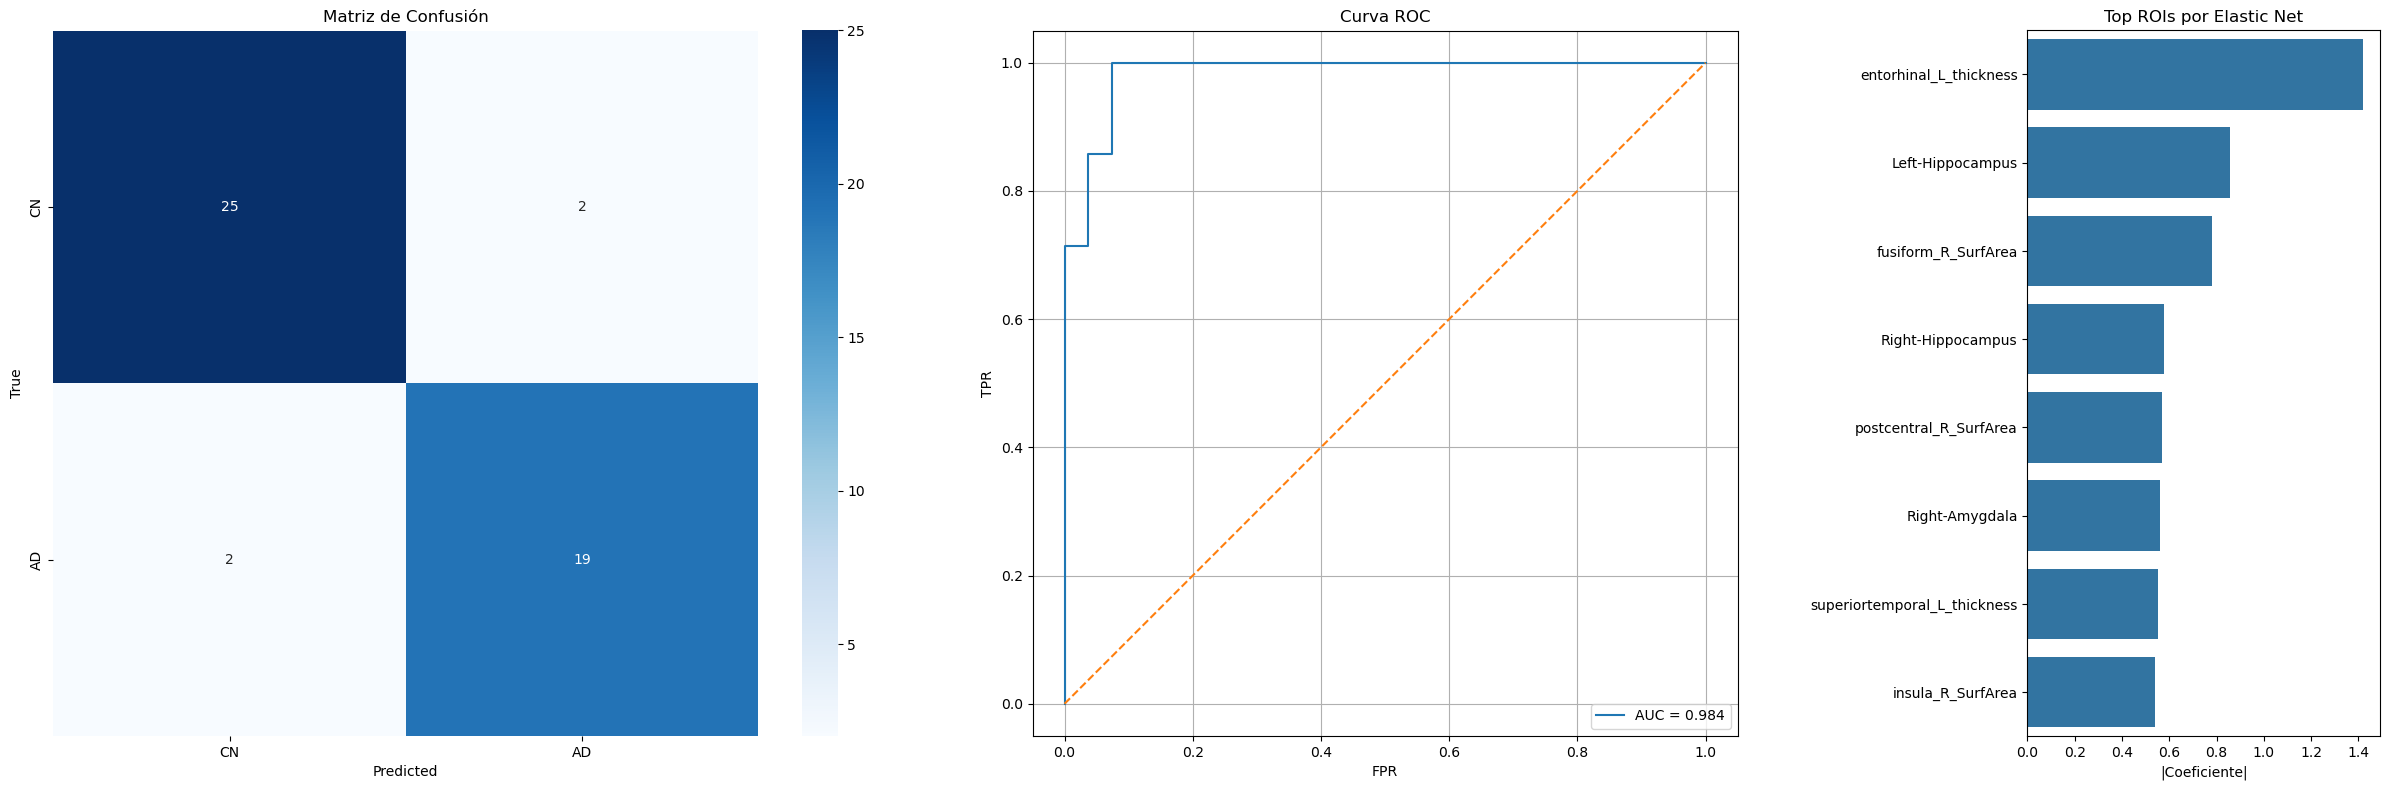


Las 8 ROIs seleccionadas son:
['Left-Hippocampus', 'Right-Hippocampus', 'Right-Amygdala', 'entorhinal_L_thickness', 'superiortemporal_L_thickness', 'fusiform_R_SurfArea', 'postcentral_R_SurfArea', 'insula_R_SurfArea']

===== RANKING COMPLETO DE FEATURES (Elastic Net) =====


,Feature,Coefficient
0,entorhinal_L_thickness,-1.420567
1,Left-Hippocampus,-0.855237
2,fusiform_R_SurfArea,-0.781358
3,Right-Hippocampus,-0.578123
4,postcentral_R_SurfArea,0.569980
5,Right-Amygdala,-0.560298
6,superiortemporal_L_thickness,-0.554191
7,insula_R_SurfArea,0.539846
8,frontalpole_R_thickness,0.529618
9,supramarginal_L_SurfArea,-0.525649


c:\Users\PcVip\miniconda3\envs\hyper_analysis\lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-04-24 15:13:50,457] A new study created in memory with name: no-name-a34da89d-c611-4d3a-916c-ac0aaf0683f7
[I 2026-04-24 15:13:50,752] Trial 0 finished with value: 0.7371212121212122 and parameters: {'n_estimators': 276, 'max_depth': 20, 'min_samples_split': 20, 'min_samples_leaf': 24}. Best is trial 0 with value: 0.7371212121212122.
[I 2026-04-24 15:13:51,212] Trial 1 finished with value: 0.7323593073593073 and parameters: {'n_estimators': 479, 'max_depth': 29, 'min_samples_split': 30, 'min_samples_leaf': 25}. Best is trial 0 with value: 0.7371212121212122.
[I 2026-04-24 15:13:51,449] Trial 2 finished with value: 0.7416666666666666 and parameters: {'n_estimators': 204, 'max_depth': 5, 'min_samples_split': 19, 'min_samples_leaf': 18}. Best is trial 2 with value


===== BEST OPTUNA RESULT — RANDOM FOREST =====
{'n_estimators': 268, 'max_depth': 24, 'min_samples_split': 27, 'min_samples_leaf': 1}
Best score: 0.7828463203463205

===== IMPORTANCIA HIPERPARAMETROS — RF =====
min_samples_leaf: 0.7912
n_estimators: 0.1891
max_depth: 0.0176
min_samples_split: 0.0021

===== RANGOS OPTIMOS (TOP 1%) — RF =====

N estimators:
count    100.000000
mean     407.160000
std      156.664456
min       47.000000
25%      389.750000
50%      409.000000
75%      455.000000
max      728.000000
Name: params_n_estimators, dtype: float64

Max depth:
count    100.000000
mean      20.940000
std        4.811224
min        9.000000
25%       18.000000
50%       22.000000
75%       24.000000
max       30.000000
Name: params_max_depth, dtype: float64

Min samples split:
count    100.000000
mean      23.100000
std        6.377834
min        7.000000
25%       24.000000
50%       25.000000
75%       27.000000
max       28.000000
Name: params_min_samples_split, dtype: float64



In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
from optuna.importance import get_param_importances

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_f.csv")
df_cn_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_cn_m.csv")
df_cn_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV", "5th-Ventricle", "Left-WM-hypointensities", "Right-WM-hypointensities", "non-WM-hypointensities", "Left-non-WM-hypointensities", "Right-non-WM-hypointensities"])
y = df["label"]

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Regresión logística con penalización Elastic Net
elastic = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    max_iter=10000,
    random_state=21,
    class_weight='balanced' 
)

# Selector de features basado en el modelo Elastic Net con balanceo de clases
selector = SelectFromModel(elastic, threshold=-np.inf)

# Pipeline completo: escalado -> selección de features -> Random Forest final
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', selector),
    ('rf',  RandomForestClassifier(random_state=34, class_weight='balanced')) # Random Forest con balanceo de clases desiguales
])

# Grid de hiperparámetros para GridSearchCV
param_grid = {
    'selector__estimator__l1_ratio': [0.3, 0.5, 0.7],
    'selector__max_features': list(range(1, 21)),
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [2, 3, 5],
    'rf__min_samples_split': [5, 10],
    'rf__min_samples_leaf': [2, 4]
}

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros encontrados
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Coeficientes del selector
coef_selector = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Índices y nombres de features seleccionadas
selected_idx = grid.best_estimator_.named_steps['selector'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1, 0.5]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot coeficientes ---
coef_df = pd.DataFrame({
    "feature": X.columns[selected_idx],
    "coef": coef_selector[selected_idx]
})

coef_df["abs_coef"] = np.abs(coef_df["coef"])
coef_df = coef_df.sort_values("abs_coef", ascending=False)

sns.barplot(data=coef_df, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por Elastic Net')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.04,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas son:")
print(feature_names.tolist())

# Extraer los coeficientes del modelo Elastic Net usado en el selector
coef_arr = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Construir DataFrame con todas las features
ranking_df = pd.DataFrame({
    'Feature': X.columns,        # Nombre de cada ROI
    'Coefficient': coef_arr,     # Coeficiente asignado por Elastic Net
})

# Ordenar por importancia global (de mayor a menor |coef|)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (Elastic Net) =====")
display(ranking_df)

# coeficientes del Elastic Net dentro del selector
selected_idx = grid.best_estimator_.named_steps['selector'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# Lectura de CSVs por grupo, diagnóstico y sexo
df_ad_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_f.csv")
df_emci_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_emci_m.csv")
df_lmci_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_lmci_m.csv")
df_emci_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_emci_f.csv")
df_lmci_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_lmci_f.csv")

# Submuestreo de grupos MCI a 30 muestras por subgrupo para balancear clases
df_emci_m = df_emci_m.sample(n=30, random_state=2)
df_emci_f = df_emci_f.sample(n=30, random_state=3)
df_lmci_m = df_lmci_m.sample(n=30, random_state=5)
df_lmci_f = df_lmci_f.sample(n=30, random_state=8)

# Crear etiquetas (label) por grupo
# 0 -> MCI (EMCI + LMCI), 1 -> AD
df_emci_m["label"] = 0
df_lmci_m["label"] = 0
df_emci_f["label"] = 0
df_lmci_f["label"] = 0
df_ad_m["label"] = 1
df_ad_f["label"] = 1

# Concatenar todos los dataframes en uno solo
df_new = pd.concat([
    df_emci_m, df_lmci_m,
    df_emci_f, df_lmci_f,
    df_ad_f, df_ad_m
], ignore_index=True)

# Separar features (usando las ROIs seleccionadas previamente) y etiquetas
X_new = df_new[feature_names]
y_new = df_new["label"].values

# Función para calcular métricas promedio con validación cruzada
def cv_metrics(pipe, X, y, cv):

    # Diccionario de métricas a evaluar
    scoring = {
        "balanced_accuracy": "balanced_accuracy",
        "precision": make_scorer(precision_score, pos_label=1),
        "recall": make_scorer(recall_score, pos_label=1),
        "f1": make_scorer(f1_score, pos_label=1),
        "accuracy": "accuracy",
        "roc_auc": "roc_auc"
    }

    results = {}

    # Calcular cada métrica mediante cross_val_score
    for name, scorer in scoring.items():
        scores = cross_val_score(pipe, X, y, cv=cv, scoring=scorer, n_jobs=-1)
        results[name] = (scores.mean(), scores.std())

    return results

# Función objetivo para optimización de hiperparámetros con Optuna
def objective_rf(trial):

    # Sugerir valores para los hiperparámetros a optimizar
    n_estimators = trial.suggest_int("n_estimators", 1, 1000)
    max_depth = trial.suggest_int("max_depth", 1, 30)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 30)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 30)

    # Crear modelo Random Forest con los parámetros sugeridos
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        class_weight="balanced",  # Fijo a "balanced" para manejar desbalanceo
        random_state=34,
        n_jobs=-1
    )

    # Pipeline simple con el modelo
    pipe = Pipeline([
        ("model", model)
    ])

    # Métrica a optimizar: balanced accuracy
    balanced_acc_scorer = make_scorer(balanced_accuracy_score)

    # Retornar el promedio de balanced accuracy en validación cruzada
    return cross_val_score(pipe, X_new, y_new, cv=cv, scoring=balanced_acc_scorer, n_jobs=-1).mean()

# Configuración y ejecución de Optuna
study_rf = optuna.create_study(
    direction="maximize",  # Maximizar la métrica objetivo
    sampler=optuna.samplers.TPESampler(n_startup_trials=5000, seed=82, multivariate=True)  # Muestreador TPE con semilla fija
)

study_rf.optimize(objective_rf, n_trials=10000)  # Ejecutar 10,000 trials de optimización

# Mostrar mejores parámetros encontrados por Optuna
print("\n===== BEST OPTUNA RESULT — RANDOM FOREST =====")
print(study_rf.best_params)
print("Best score:", study_rf.best_value)

# Calcular importancia de cada hiperparámetro en la optimización
importances_rf = get_param_importances(study_rf)

print("\n===== IMPORTANCIA HIPERPARAMETROS — RF =====")
for k, v in importances_rf.items():
    print(f"{k}: {v:.4f}")

# Extraer rangos óptimos del top 1% de los trials
trials_df_rf = study_rf.trials_dataframe()
top_n_rf = int(len(trials_df_rf) * 0.01)  # Calcular 1% del total de trials
top_trials_rf = trials_df_rf.sort_values("value", ascending=False).head(top_n_rf)

print("\n===== RANGOS OPTIMOS (TOP 1%) — RF =====")

# Mostrar estadísticas descriptivas de los mejores hiperparámetros
print("\nN estimators:")
print(top_trials_rf["params_n_estimators"].describe())

print("\nMax depth:")
print(top_trials_rf["params_max_depth"].describe())

print("\nMin samples split:")
print(top_trials_rf["params_min_samples_split"].describe())

print("\nMin samples leaf:")
print(top_trials_rf["params_min_samples_leaf"].describe())

# División estratificada en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_new, y_new, test_size=0.2, stratify=y_new, random_state=13
)

# Recuperar mejores hiperparámetros encontrados por Optuna
best_rf = study_rf.best_params

# Construir modelo Random Forest final con los mejores parámetros
rf_final = RandomForestClassifier(
    n_estimators=best_rf["n_estimators"],
    max_depth=best_rf["max_depth"],
    min_samples_split=best_rf["min_samples_split"],
    min_samples_leaf=best_rf["min_samples_leaf"],
    class_weight="balanced",  # Fijo a "balanced"
    random_state=34,
    n_jobs=-1
)

# Pipeline final
pipe_final_rf = Pipeline([
    ("model", rf_final)
])

# Entrenar el modelo final
pipe_final_rf.fit(X_train, y_train)

# Predicciones sobre conjunto de test
y_pred_rf = pipe_final_rf.predict(X_test)
y_prob_rf = pipe_final_rf.predict_proba(X_test)[:, 1]

print("\n===== CV METRICS — RANDOM FOREST =====")
cv_rf = cv_metrics(pipe_final_rf, X_new, y_new, cv)

for k, v in cv_rf.items():
    print(f"{k}: {v[0]:.3f} ± {v[1]:.3f}")

print("\n===== TEST METRICS — RANDOM FOREST =====")

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_rf))


features seleccionadas (8):
['Left-Hippocampus', 'Right-Hippocampus', 'Right-Amygdala', 'entorhinal_L_thickness', 'superiortemporal_L_thickness', 'fusiform_R_SurfArea', 'postcentral_R_SurfArea', 'insula_R_SurfArea']

distribucion de clases:
0    120
1    107
Name: count, dtype: int64
Fitting 5 folds for each of 26880 candidates, totalling 134400 fits

Mejores parametros encontrados
mejor balanced_accuracy cv: 0.7521

parametros optimos:
  rf__class_weight: balanced
  rf__max_depth: 10
  rf__min_samples_leaf: 2
  rf__min_samples_split: 29
  rf__n_estimators: 416

--- metricas de validacion cruzada (mejor modelo) ---
balanced accuracy cv: 0.752
f1-score cv: 0.742
precision cv: 0.723
recall cv: 0.765
specificity cv: 0.739
roc-auc cv: 0.805

umbral optimo: 0.512

--- metricas sobre test (con threshold ajustado) ---
balanced accuracy: 0.739
f1-score: 0.727
precision: 0.727
recall (sensibilidad ad): 0.727
specificity (mci): 0.750
roc-auc: 0.752

comparacion de thresholds

--- threshold por 

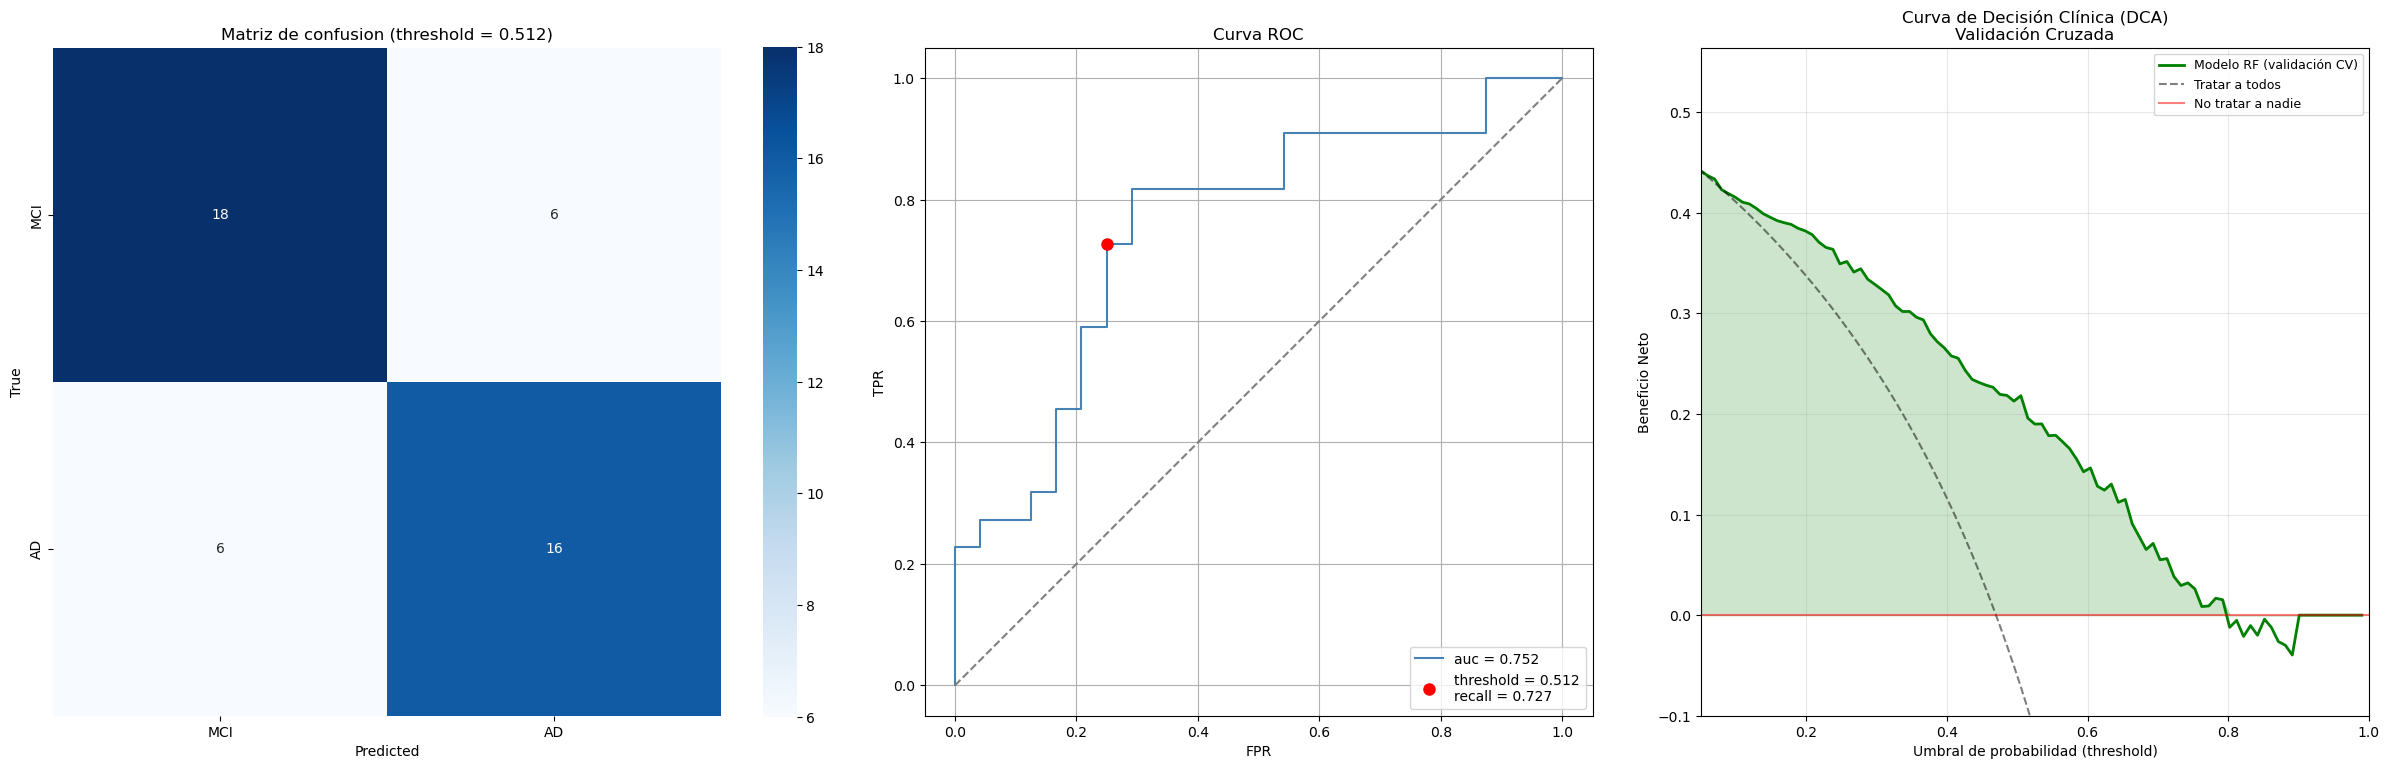

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    precision_recall_curve,
    roc_curve,
    auc,
    make_scorer,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    recall_score
)

import seaborn as sns
import matplotlib.pyplot as plt

# selecciona las caracteristicas que fueron elegidas por el selector del mejor modelo
selected_idx = grid.best_estimator_.named_steps['selector'].get_support(indices=True)
selected_features = X.columns[selected_idx]

print(f"\nfeatures seleccionadas ({len(selected_features)}):")
print(selected_features.tolist())

# Lectura de CSVs por grupo y sexo
df_ad_m   = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_m.csv")
df_ad_f   = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_f.csv")
df_emci_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_emci_m.csv")
df_emci_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_emci_f.csv")
df_lmci_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_lmci_m.csv")
df_lmci_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_lmci_f.csv")

# Balanceo manual para igualar el numero de muestras entre grupos
df_emci_m = df_emci_m.sample(n=30, random_state=2)
df_emci_f = df_emci_f.sample(n=30, random_state=3)
df_lmci_m = df_lmci_m.sample(n=30, random_state=5)
df_lmci_f = df_lmci_f.sample(n=30, random_state=8)

# Crear etiquetas (label) por grupo
# 0 -> MCI, 1 -> AD
df_ad_m["label"]   = 1
df_ad_f["label"]   = 1
df_emci_m["label"] = 0
df_emci_f["label"] = 0
df_lmci_m["label"] = 0
df_lmci_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df_new = pd.concat([df_emci_m, df_lmci_m, df_emci_f, df_lmci_f, df_ad_f, df_ad_m], ignore_index=True)

# Separar features (X) y etiquetas (y) usando solo las features seleccionadas
X_new = df_new[selected_features]
y_new = df_new["label"].values

print("\ndistribucion de clases:")
print(pd.Series(y_new).value_counts())

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X_new, y_new, test_size=0.2, stratify=y_new, random_state=13
)

# Configuración de GridSearchCV
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Estandarización de features
    ('rf', RandomForestClassifier(random_state=34))  # Random Forest con semilla fija
])

# Grid de hiperparámetros para GridSearchCV
param_grid = {
    'rf__min_samples_leaf': [1,2],                    # Mínimo de muestras en hoja
    'rf__min_samples_split': list(range(24, 31)),     # Mínimo de muestras para dividir nodo
    'rf__n_estimators': list(range(350, 470)),        # Número de árboles en el bosque
    'rf__max_depth': list(range(10, 26)),             # Profundidad máxima del árbol
    'rf__class_weight': ["balanced"]                  # Balanceo automático de clases
}

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid_new = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,
    refit='balanced_accuracy',  # Optimizar basado en balanced accuracy
    n_jobs=-1,                  # Usar todos los cores disponibles
    verbose=2                   # Mostrar progreso
)

# Entrenamiento del GridSearch
grid_new.fit(X_train, y_train)

print("\n" + "="*60)
print("Mejores parametros encontrados")
print("="*60)
print(f"mejor balanced_accuracy cv: {grid_new.best_score_:.4f}")
print("\nparametros optimos:")
for param, value in grid_new.best_params_.items():
    print(f"  {param}: {value}")

# Métricas de validación cruzada para el mejor modelo
best_idx = grid_new.best_index_
f1_cv           = grid_new.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid_new.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid_new.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid_new.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid_new.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid_new.cv_results_['mean_test_specificity'][best_idx]

print("\n--- metricas de validacion cruzada (mejor modelo) ---")
print(f"balanced accuracy cv: {balanced_acc_cv:.3f}")
print(f"f1-score cv: {f1_cv:.3f}")
print(f"precision cv: {precision_cv:.3f}")
print(f"recall cv: {recall_cv:.3f}")
print(f"specificity cv: {specificity_cv:.3f}")
print(f"roc-auc cv: {roc_auc_cv:.3f}")

# Predicción sobre set de test con umbral por defecto
y_pred = grid_new.predict(X_test)
y_prob_ad = grid_new.predict_proba(X_test)[:, 1]

# Recall minimo deseado para la clase AD
min_recall_ad = 0.75

# Calculo de probabilidades out-of-fold en validacion para encontrar el umbral optimo
y_prob_cv = cross_val_predict(
    grid_new.best_estimator_,
    X_train,
    y_train,
    cv=cv,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

# Calculo de la curva precision-recall para encontrar el umbral optimo
prec_arr, rec_arr, thr_arr = precision_recall_curve(
    y_train, y_prob_cv)

# Encontrar indices donde el recall es mayor o igual al minimo requerido
idx = np.where(rec_arr >= min_recall_ad)[0]

if len(idx) > 0:
    best = idx[np.argmax(prec_arr[idx])]  # Entre los que cumplen, elegir el de mayor precision
else:
    best = np.argmax(prec_arr)  # Si ninguno cumple, elegir el de mayor precision global

# Selecciona el umbral optimo
optimal_threshold = thr_arr[min(best, len(thr_arr)-1)]

# Aplica el umbral ajustado a las predicciones de test
y_pred_adj = np.where(y_prob_ad >= optimal_threshold, 1, 0)

print(f"\numbral optimo: {optimal_threshold:.3f}")

# Calculo de metricas con predicciones ajustadas
f1 = f1_score(y_test, y_pred_adj)
roc_auc = roc_auc_score(y_test, y_prob_ad)
balanced_acc = balanced_accuracy_score(y_test, y_pred_adj)
precision = precision_score(y_test, y_pred_adj)
recall = recall_score(y_test, y_pred_adj)

# Especificidad usando confusion_matrix.ravel()
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_adj).ravel()
specificity = tn / (tn + fp)

print("\n--- metricas sobre test (con threshold ajustado) ---")
print(f"balanced accuracy: {balanced_acc:.3f}")
print(f"f1-score: {f1:.3f}")
print(f"precision: {precision:.3f}")
print(f"recall (sensibilidad ad): {recall:.3f}")
print(f"specificity (mci): {specificity:.3f}")
print(f"roc-auc: {roc_auc:.3f}")
print("\n" + "="*60)
print("comparacion de thresholds")
print("="*60)

# Métricas con threshold por defecto (0.5) para comparar
f1_default = f1_score(y_test, y_pred)
balanced_acc_default = balanced_accuracy_score(y_test, y_pred)
precision_default = precision_score(y_test, y_pred)
recall_default = recall_score(y_test, y_pred)
tn_def, fp_def, fn_def, tp_def = confusion_matrix(y_test, y_pred).ravel()
specificity_default = tn_def / (tn_def + fp_def)

print("\n--- threshold por defecto (0.5) ---")
print(f"balanced accuracy: {balanced_acc_default:.3f}")
print(f"f1-score: {f1_default:.3f}")
print(f"precision: {precision_default:.3f}")
print(f"recall: {recall_default:.3f}")
print(f"specificity: {specificity_default:.3f}")
print(f"roc-auc: {roc_auc:.3f}")

print(f"\n--- threshold ajustado ({optimal_threshold:.3f}) ---")
print(f"balanced accuracy: {balanced_acc:.3f}")
print(f"f1-score: {f1:.3f}")
print(f"precision: {precision:.3f}")
print(f"recall: {recall:.3f}")
print(f"specificity: {specificity:.3f}")
print(f"roc-auc: {roc_auc:.3f}")

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1, 1]}
)

# --- Matriz de confusión (con threshold ajustado) ---
cm = confusion_matrix(y_test, y_pred_adj, labels=[0, 1])
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['MCI', 'AD'],
    yticklabels=['MCI', 'AD'],
    ax=axes[0],
    cbar=True, cbar_kws={'shrink': 0.87}
)
axes[0].set_title(f"Matriz de confusion (threshold = {optimal_threshold:.3f})")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob_ad)
auc_value = auc(fpr, tpr)
axes[1].plot(fpr, tpr, label=f'auc = {auc_value:.3f}', color='steelblue')
axes[1].plot([0, 1], [0, 1], '--', color='gray')

# Marca el punto del threshold optimo en la curva roc
fpr_opt = fpr[np.argmax(tpr >= recall)] if len(fpr) > 0 and np.any(tpr >= recall) else 0
tpr_opt = recall
axes[1].plot(fpr_opt, tpr_opt, 'ro', markersize=8, label=f'threshold = {optimal_threshold:.3f}\nrecall = {recall:.3f}')

axes[1].set_title("Curva ROC")
axes[1].set_xlabel("FPR")
axes[1].set_ylabel("TPR")
axes[1].legend(loc='lower right')
axes[1].grid(True)
axes[1].set_box_aspect(1)

# Función para calcular beneficio neto en análisis de curvas de decisión (DCA)
def calculate_net_benefit(y_true, probas, threshold):

    # Calcular verdaderos positivos: muestras con probabilidad >= umbral Y clase real = 1 (AD)
    tp = np.sum((probas >= threshold) & (y_true == 1))

    # Calcular falsos positivos: muestras con probabilidad >= umbral Y clase real = 0 (MCI)
    fp = np.sum((probas >= threshold) & (y_true == 0))

    # Número total de muestras en el conjunto
    n = len(y_true)

    # Evitar división por cero cuando threshold es 0 o 1
    if threshold == 1 or threshold == 0:
        return 0
    return (tp / n) - (fp / n) * (threshold / (1 - threshold))

# Usar probabilidades OOF (Out-Of-Fold) de validación cruzada (NO test) para evitar sobreajuste
y_prob_cv_dca = cross_val_predict(
    grid_new.best_estimator_,
    X_train,
    y_train,
    cv=cv,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

# Generar curvas DCA usando validación cruzada
thresholds_dca = np.linspace(0.01, 0.99, 100)
net_benefit_model = [calculate_net_benefit(y_train, y_prob_cv_dca, t) for t in thresholds_dca]
net_benefit_all = [calculate_net_benefit(y_train, np.ones(len(y_train)), t) for t in thresholds_dca]

# Graficar DCA
axes[2].plot(thresholds_dca, net_benefit_model, color='green', linewidth=2, label='Modelo RF (validación CV)')
axes[2].plot(thresholds_dca, net_benefit_all, color='black', linestyle='--', alpha=0.5, label='Tratar a todos')
axes[2].axhline(y=0, color='red', linestyle='-', alpha=0.5, label='No tratar a nadie')

axes[2].set_xlim(0.05, 1)
axes[2].set_ylim(-0.1, max(net_benefit_model) + 0.1)
axes[2].set_title("Curva de Decisión Clínica (DCA)\nValidación Cruzada")
axes[2].set_xlabel("Umbral de probabilidad (threshold)")
axes[2].set_ylabel("Beneficio Neto")
axes[2].legend(loc='best', fontsize=9)
axes[2].grid(True, alpha=0.3)
axes[2].set_box_aspect(1)

# Añadir región de beneficio positivo (sombreado verde donde el modelo supera el baseline)
y_fill = np.maximum(net_benefit_model, 0)
axes[2].fill_between(thresholds_dca, 0, y_fill, alpha=0.2, color='green')

# Ajustar layout y posiciones de los subplots para mejor visualización
plt.tight_layout()
plt.subplots_adjust(wspace=0.1)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.015,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()